In [2]:
import os
import fitz  # PyMuPDF
import pandas as pd

# Define your root dataset directory here
DATA_DIR = "./dataset"

data = []

# Iterate through folder categories and read PDFs
for category in os.listdir(DATA_DIR):
    category_path = os.path.join(DATA_DIR, category)
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.endswith(".pdf"):
                file_path = os.path.join(category_path, filename)
                try:
                    # Extract text from PDF
                    doc = fitz.open(file_path)
                    text = ""
                    for page in doc:
                        text += page.get_text("text") + " "
                    doc.close()

                    data.append({
                        "file_name": filename,
                        "category": category,
                        "raw_text": text
                    })
                except Exception as e:
                    print(f"Error reading {filename}: {e}")

df = pd.DataFrame(data)
print(f"Total documents extracted: {len(df)}")
# We will save to CSV after cleaning

Total documents extracted: 50


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Lowercase conversion
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Normalize extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization, stop-word removal, and short token removal (length < 3)
    tokens = word_tokenize(text)
    cleaned_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    return " ".join(cleaned_tokens)

# Apply cleaning
df['cleaned_text'] = df['raw_text'].apply(clean_text)

# Save the structured CSV
df.to_csv("cleaned_corpus.csv", index=False)
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hyperlink\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hyperlink\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,file_name,category,raw_text,cleaned_text
0,1597735884.pdf,Business,AN INTRODUCTION TO MARKETING \nKangkana Chaud...,introduction marketing kangkana chaudhury mcom...
1,9781405130080_4_011.pdf,Business,..\nLeadership\nKey Terms\ncharismatic leaders...,leadership key terms charismatic leadership pr...
2,Basics-of-Accounting.pdf,Business,\n \n \n \n \n \n \n \n \n \n \n \n \n \n \n ...,basics accounting type contents introduction a...
3,BeginnersGuidetoBranding.pdf,Business,1\n 2\nInside\n4\nINTRODUCTION TO BRANDING\nYo...,inside introduction branding probably hear ter...
4,Booklet_1.pdf,Business,Kingdom of Saudi Arabia\nCapital Market Author...,kingdom saudi arabia capital market authority ...


Training models on Unigrams...
Training models on Bigrams...
Training models on Trigrams...

--- Model Evaluation Results ---
              Model  N-Gram  Accuracy  Precision  Recall  F1-Score
Logistic Regression Unigram       0.7        1.0     0.7  0.813333
        Naive Bayes Unigram       0.8        1.0     0.8  0.873333
Logistic Regression  Bigram       0.2        0.5     0.2  0.283333
        Naive Bayes  Bigram       0.2        0.5     0.2  0.283333
Logistic Regression Trigram       0.0        0.0     0.0  0.000000
        Naive Bayes Trigram       0.0        0.0     0.0  0.000000


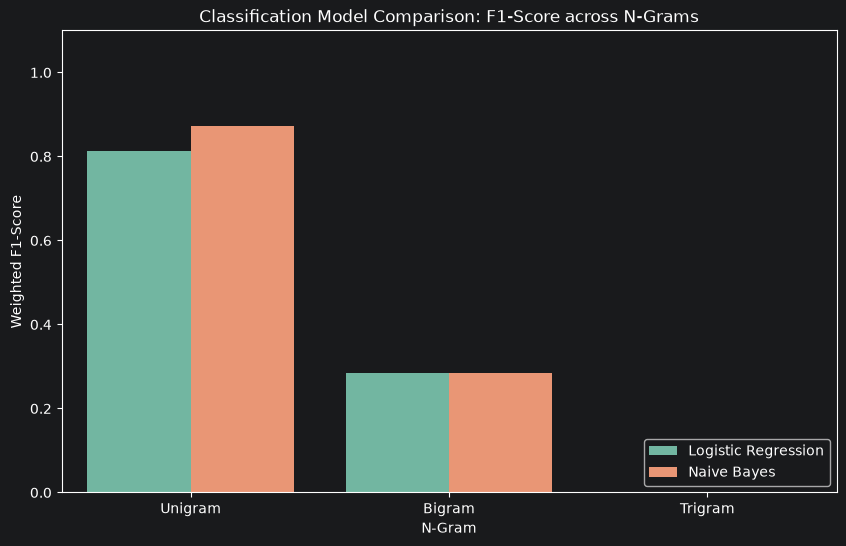


Plotting Confusion Matrix for the best model: Naive Bayes (Unigram) with F1: 0.8733


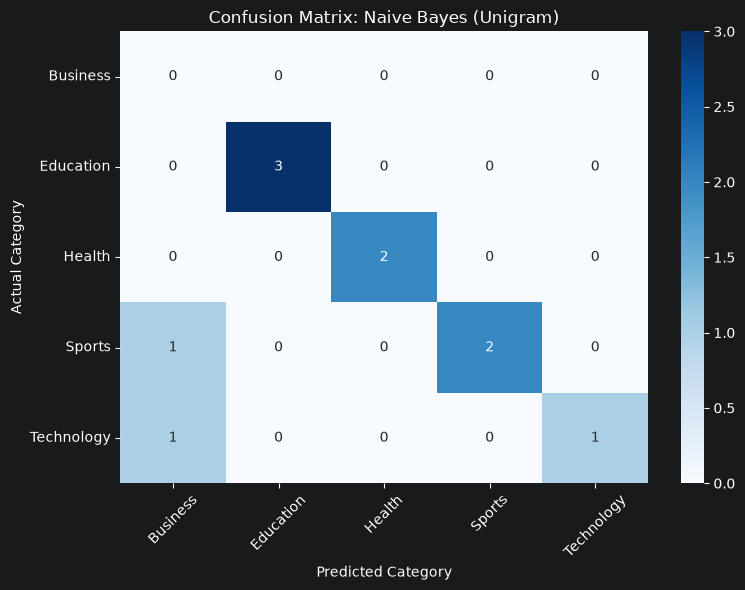

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# N-Gram configurations mapping
ngram_configs = {
    "Unigram": (1, 1),
    "Bigram": (2, 2),
    "Trigram": (3, 3)
}

results = []
best_f1 = 0
best_model_name = ""
best_model_ngram = ""
best_y_test = None
best_preds = None
best_classes = None

# Ensure the column name matches your dataframe ('cleaned_text' and 'category')
X_text = df['cleaned_text']
y_labels = df['category']

for name, ngram_range in ngram_configs.items():
    print(f"Training models on {name}s...")

    # Vectorize text
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=2000)
    X = vectorizer.fit_transform(X_text)

    X_train, X_test, y_train, y_test = train_test_split(X, y_labels, test_size=0.2, random_state=42)

    # --- 1. Logistic Regression ---
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    lr_preds = lr.predict(X_test)

    lr_f1 = f1_score(y_test, lr_preds, average='weighted', zero_division=0)
    results.append({
        "Model": "Logistic Regression", "N-Gram": name,
        "Accuracy": accuracy_score(y_test, lr_preds),
        "Precision": precision_score(y_test, lr_preds, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, lr_preds, average='weighted', zero_division=0),
        "F1-Score": lr_f1
    })

    # Check if this is the best model so far
    if lr_f1 > best_f1:
        best_f1 = lr_f1
        best_model_name = "Logistic Regression"
        best_model_ngram = name
        best_y_test = y_test
        best_preds = lr_preds
        best_classes = lr.classes_

    # --- 2. Naive Bayes ---
    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    nb_preds = nb.predict(X_test)

    nb_f1 = f1_score(y_test, nb_preds, average='weighted', zero_division=0)
    results.append({
        "Model": "Naive Bayes", "N-Gram": name,
        "Accuracy": accuracy_score(y_test, nb_preds),
        "Precision": precision_score(y_test, nb_preds, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, nb_preds, average='weighted', zero_division=0),
        "F1-Score": nb_f1
    })

    # Check if this is the best model so far
    if nb_f1 > best_f1:
        best_f1 = nb_f1
        best_model_name = "Naive Bayes"
        best_model_ngram = name
        best_y_test = y_test
        best_preds = nb_preds
        best_classes = nb.classes_

# Convert results to DataFrame for clean display
results_df = pd.DataFrame(results)
print("\n--- Model Evaluation Results ---")
print(results_df.to_string(index=False))

# --- Classification Model Comparison Graph ---
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='N-Gram', y='F1-Score', hue='Model', palette='Set2')
plt.title("Classification Model Comparison: F1-Score across N-Grams")
plt.ylabel("Weighted F1-Score")
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

# --- Confusion Matrix for the BEST Model ---
print(f"\nPlotting Confusion Matrix for the best model: {best_model_name} ({best_model_ngram}) with F1: {best_f1:.4f}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(best_y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_classes, yticklabels=best_classes)
plt.title(f"Confusion Matrix: {best_model_name} ({best_model_ngram})")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Training all 6 Word2Vec models to compare execution time...

--- Training Time Results ---
N-Gram Level     Model  Training Time (s)
     Unigram      CBOW           2.216584
     Unigram Skip-gram           9.301181
      Bigram      CBOW           8.796950
      Bigram Skip-gram          15.183742
     Trigram      CBOW           7.777281
     Trigram Skip-gram          16.812522


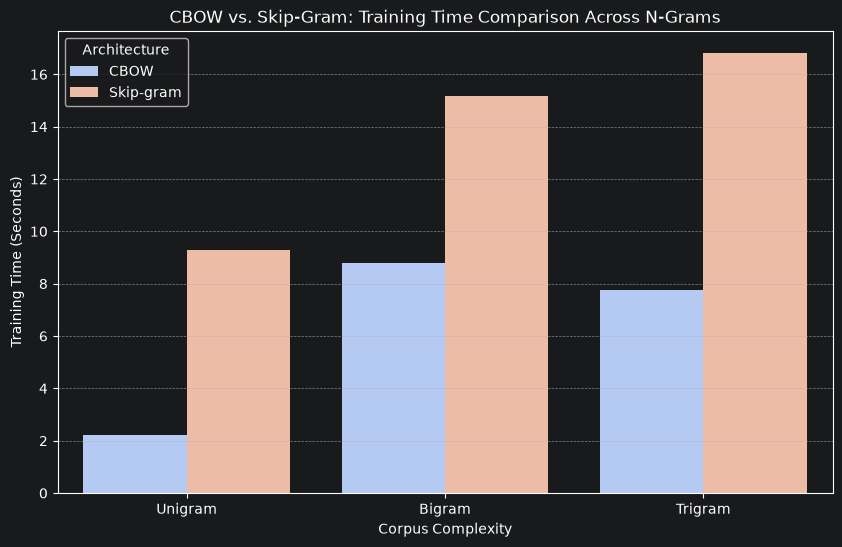

In [11]:
import time
from gensim.models import Word2Vec
from nltk import ngrams

# Prepare sentences for Word2Vec (Unigram, Bigram, Trigram tokens)
tokens_list = [text.split() for text in df['cleaned_text']]
unigram_sentences = tokens_list
bigram_sentences = [["_".join(bg) for bg in ngrams(tokens, 2)] for tokens in tokens_list]
trigram_sentences = [["_".join(tg) for tg in ngrams(tokens, 3)] for tokens in tokens_list]

# Initialize dictionary to store our metrics
comparison_data = {
    "N-Gram Level": ["Unigram", "Unigram", "Bigram", "Bigram", "Trigram", "Trigram"],
    "Model": ["CBOW", "Skip-gram", "CBOW", "Skip-gram", "CBOW", "Skip-gram"],
    "Training Time (s)": []
}

# Helper function to train and measure execution time
def train_and_time(sentences, sg_val):
    if not sentences or all(len(s) == 0 for s in sentences):
        return 0
    start_time = time.time()
    # sg=0 is CBOW, sg=1 is Skip-gram
    model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=1, sg=sg_val)
    end_time = time.time()
    return end_time - start_time

print("Training all 6 Word2Vec models to compare execution time...")

# 1. Unigrams
comparison_data["Training Time (s)"].append(train_and_time(unigram_sentences, 0))
comparison_data["Training Time (s)"].append(train_and_time(unigram_sentences, 1))

# 2. Bigrams
comparison_data["Training Time (s)"].append(train_and_time(bigram_sentences, 0))
comparison_data["Training Time (s)"].append(train_and_time(bigram_sentences, 1))

# 3. Trigrams
comparison_data["Training Time (s)"].append(train_and_time(trigram_sentences, 0))
comparison_data["Training Time (s)"].append(train_and_time(trigram_sentences, 1))

# Convert to DataFrame for Seaborn
df_times = pd.DataFrame(comparison_data)

# Print tabular results
print("\n--- Training Time Results ---")
print(df_times.to_string(index=False))

# --- CBOW vs Skip-Gram Comparison Graph ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_times, x="N-Gram Level", y="Training Time (s)", hue="Model", palette="coolwarm")
plt.title("CBOW vs. Skip-Gram: Training Time Comparison Across N-Grams")
plt.ylabel("Training Time (Seconds)")
plt.xlabel("Corpus Complexity")
plt.legend(title="Architecture")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

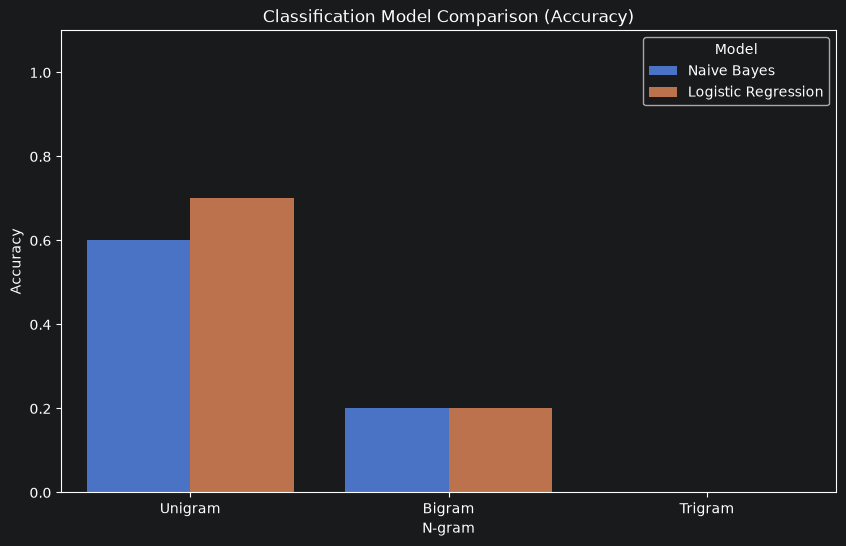

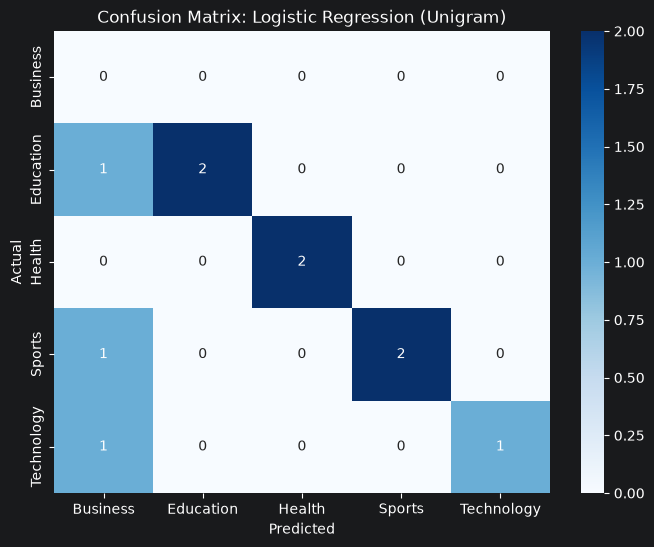

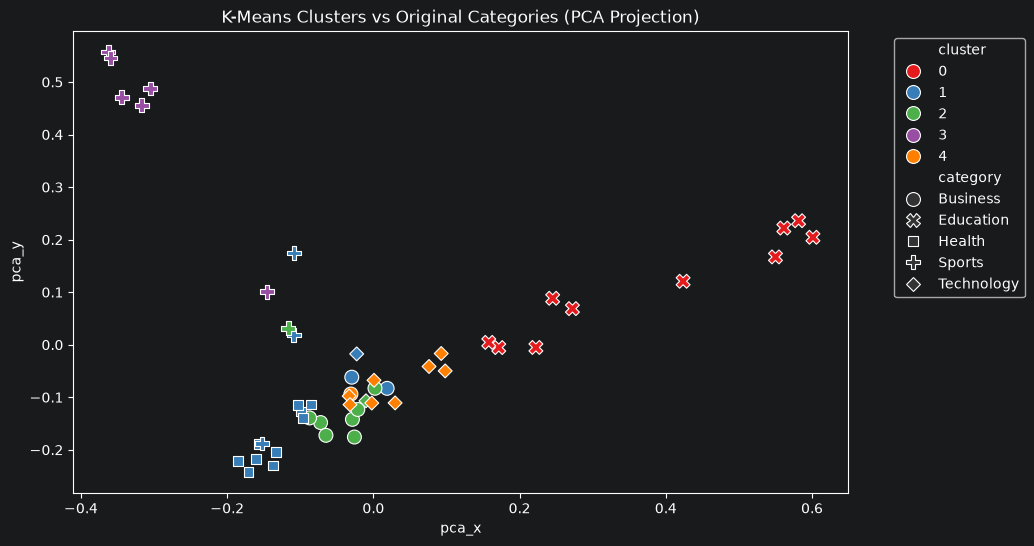

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

# K-Means Clustering
# Using Unigram TF-IDF for clustering entire dataset
vectorizer_km = TfidfVectorizer(ngram_range=(1,1))
X_km = vectorizer_km.fit_transform(df['cleaned_text'])

num_clusters = len(df['category'].unique())
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_km)

# K-Means Visualization using PCA
pca = PCA(n_components=2)
scatter_coords = pca.fit_transform(X_km.toarray())
df['pca_x'] = scatter_coords[:, 0]
df['pca_y'] = scatter_coords[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_x', y='pca_y', hue='cluster', style='category', palette='Set1', s=100)
plt.title("K-Means Clusters vs Original Categories (PCA Projection)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()